# 💳 260219_FeatureEngineering_신용거래이상탐지데이터
## 🎯 목표 설정 : 신용거래 이상탐지 모델 생성
- 신용거래 이상탐지 모델로 사기거래를 탐지하라!!!

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('fraud.csv')

In [307]:
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,...,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,...,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,...,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,...,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [308]:
data.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
491129,2020-12-31 23:56:48,6011109736646996,fraud_Botsford and Sons,home,134.26,Rebecca,Erickson,F,594 Berry Lights Apt. 392,Wilmington,...,34.2651,-77.8670,186140,English as a second language teacher,1983-02-08,fc860b0d1f89b0b068c9c8db27b6bcc5,1388534208,34.853497,-78.664158,0
491130,2020-12-31 23:56:57,213112402583773,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,25.49,Ana,Howell,F,4664 Sanchez Common Suite 930,Bradley,...,34.0326,-82.2027,1523,Research scientist (physical sciences),1984-06-03,0f0c38fe781b317f733b845c0d6ba448,1388534217,35.008839,-81.475156,0
491131,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,...,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
491132,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,...,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
491133,2020-12-31 23:59:34,4170689372027579,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,Edmond,...,35.6665,-97.4798,116001,Media buyer,1993-05-10,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0


In [309]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  491134 non-null  object 
 1   cc_num                 491134 non-null  int64  
 2   merchant               491134 non-null  object 
 3   category               491134 non-null  object 
 4   amt                    491134 non-null  float64
 5   first                  491134 non-null  object 
 6   last                   491134 non-null  object 
 7   gender                 491134 non-null  object 
 8   street                 491134 non-null  object 
 9   city                   491134 non-null  object 
 10  state                  491134 non-null  object 
 11  zip                    491134 non-null  int64  
 12  lat                    491134 non-null  float64
 13  long                   491134 non-null  float64
 14  city_pop               491134 non-nu

## 📌 컬럼 설명
1️⃣ 거래 관련 정보 (Transaction Information)
|컬럼명	|의미	|설명|
|---|---|---|
|trans_date_trans_time|	거래 발생 일시	|거래가 발생한 날짜 + 시간  (2019-01-01 00:00:44)|
|amt|	거래 금액|	해당 거래의 결제 금액|
|trans_num|	거래 고유번호|	각 거래를 식별하는 고유 ID|
|unix_time|	유닉스 타임	|거래 시각을 초 단위 숫자로 표현한 값  (1970년 1월 1일부터 경과 초)|
|is_fraud|	사기 여부 |	1 = 사기 거래, 0 = 정상 거래|
|category|	가맹점 카테고리	| grocery, shopping, travel 등|
|merchant|	가맹점 이름	|결제가 발생한 상점 이름|
|merch_lat|	가맹점 위도	|상점 위치 위도|
|merch_long|	가맹점 경도|	상점 위치 경도|

2️⃣ 고객(카드 소유자) 정보 (Customer Information)
|컬럼명	|의미	|설명|
|---|---|---|
|cc_num	|카드 번호|	카드 고유 번호 (식별자 역할)|
|first	|이름|	고객 이름|
|last	|성	|고객 성|
|gender	|성별|	M / F|
|dob	|생년월일|	1994-07-05|
|job	|직업|	고객 직업|
|street	|주소|	거리 주소|
|city	|도시|	거주 도시|
|state	|주	|거주 주|
|zip	|우편번호	|거주 우편번호|
|lat	|고객 위치 위도	|거주지 위도|
|long	|고객 위치 경도	|거주지 경도|
|city_pop|	도시 인구	|고객이 거주하는 도시의 인구 수|

In [310]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [311]:
data['is_fraud'].value_counts()

is_fraud
0    489890
1      1244
Name: count, dtype: int64

In [312]:
data['category'].value_counts()

category
shopping_pos      48345
gas_transport     46029
home              43340
grocery_pos       42722
kids_pets         40295
shopping_net      39179
food_dining       35980
personal_care     35513
entertainment     33619
misc_pos          32411
health_fitness    31415
misc_net          25179
grocery_net       24486
travel            12621
Name: count, dtype: int64

In [313]:
data['merchant'].value_counts()

merchant
fraud_Kilback LLC                      1602
fraud_Cormier LLC                      1455
fraud_Kuhn LLC                         1446
fraud_Schumm PLC                       1392
fraud_Boyer PLC                        1375
                                       ... 
fraud_Little-Gleichner                  228
fraud_Douglas, DuBuque and McKenzie     228
fraud_Satterfield-Lowe                  227
fraud_Reichert-Weissnat                 226
fraud_Jerde-Hermann                     226
Name: count, Length: 693, dtype: int64

In [314]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000
mean,3.706013e+17,69.050120,50770.532384,37.931230,-90.495619,1.213922e+05,1.358730e+09,37.930272,-90.495411,0.002533
std,1.260229e+18,160.322867,26854.947965,5.341193,12.990732,3.725751e+05,1.819402e+07,5.372986,13.004100,0.050264
min,5.038744e+11,1.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1.325376e+09,23.655789,-123.345106,0.000000
25%,2.131124e+14,8.960000,28405.000000,33.746700,-97.235100,1.228000e+03,1.343087e+09,33.781388,-96.984814,0.000000
50%,3.531130e+15,42.170000,49628.000000,38.507200,-87.591700,5.760000e+03,1.357257e+09,38.545124,-87.573441,0.000000
75%,4.653879e+15,80.330000,75048.000000,41.520500,-80.731000,5.083500e+04,1.374626e+09,41.624294,-80.685567,0.000000
max,4.956829e+18,25086.940000,99323.000000,48.887800,-69.965600,2.906700e+06,1.388534e+09,49.887523,-68.965624,1.000000


## Step 1 - 1. 사기거래 여부를 예측하는 데 불필요한 컬럼을 제거합니다.
- 거래 고유 ID, 카드 번호는 사람 구분하는 컬럼이기 때문에 사기거래 여부에는 불필요하다는 판단
- 이름도 사기와 직접 관련 있을 가능성 없다고 판단
- 상세주소, 가맹점 이름 데이터가 너무 구체적이고 텍스트라 활용 불가능하다고 판단

In [315]:
drop_data = data.drop(columns=["trans_num", "cc_num", "first", "last", "street", "merchant"])

In [316]:
drop_data.head()

,trans_date_trans_time,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1325377421,29.737426,-90.853194,0


## Step 1 - 2. 최소 2개 이상의 새로운 피처(변수)를 생성해봅시다.

### 1) 시간대(hour) & 새벽/심야(is_night) 변수
시간대 변수 만들고 새벽/심야 23시~05시 거래는 정상 패턴과 다를 때가 많아 사기 탐지에 유용할 듯

In [317]:
drop_data["trans_date_trans_time"] = pd.to_datetime(drop_data["trans_date_trans_time"])

In [318]:
drop_data["hour"] = drop_data["trans_date_trans_time"].dt.hour

In [319]:
drop_data["is_night"] = ((drop_data["hour"] >= 22) | (drop_data["hour"] <= 4)).astype(int)


In [320]:
drop_data['is_night'].value_counts()

is_night
0    374574
1    116560
Name: count, dtype: int64

### 2) 요일(day_of_week) 변수
요일별 숫자로 변화하여 요일별 소비 패턴을 알 수 있음

In [321]:
drop_data["day_of_week"] = drop_data["trans_date_trans_time"].dt.dayofweek

### 3) 주말 여부(is_weekend) 변수 
주말이면 1, 평일이면 0

In [322]:
drop_data["is_weekend"] = drop_data["day_of_week"].isin([5,6]).astype(int)

In [323]:
drop_data["dob"] = pd.to_datetime(drop_data["dob"])
drop_data["age"] = drop_data["trans_date_trans_time"].dt.year - drop_data["dob"].dt.year

### 4) 나이(age) 변수
생년월일과 거래 발생 연도를 활용하여 대략적인 나이 활용

In [324]:
drop_data["age"] = drop_data["trans_date_trans_time"].dt.year - drop_data["dob"].dt.year

In [325]:
drop_data.head()

,trans_date_trans_time,category,amt,gender,city,state,zip,lat,long,city_pop,...,dob,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,day_of_week,is_weekend,age
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,...,1978-06-21,1325376044,49.159047,-118.186462,0,0,1,1,0,41
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,7208,40.6747,-74.2239,124967,...,1980-12-21,1325376754,40.079588,-74.848087,0,0,1,1,0,39
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,7060,40.6152,-74.4150,71485,...,1974-07-19,1325377036,40.021888,-74.228188,0,0,1,1,0,45
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,48174,42.2203,-83.3583,31515,...,1971-11-05,1325377215,42.360426,-83.552316,0,0,1,1,0,48
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,70808,30.4066,-91.1468,378909,...,1977-02-22,1325377421,29.737426,-90.853194,0,0,1,1,0,42


In [326]:
drop_data["day_of_week"].sort_values()

121879    0
80468     0
80467     0
80466     0
80465     0
         ..
131152    6
131153    6
131154    6
131140    6
126091    6
Name: day_of_week, Length: 491134, dtype: int32

<Axes: ylabel='amt'>

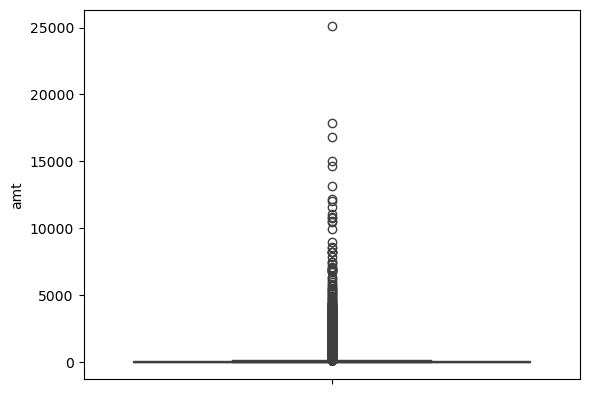

In [327]:
sns.boxplot(drop_data["amt"])

<Axes: xlabel='None', ylabel='amt'>

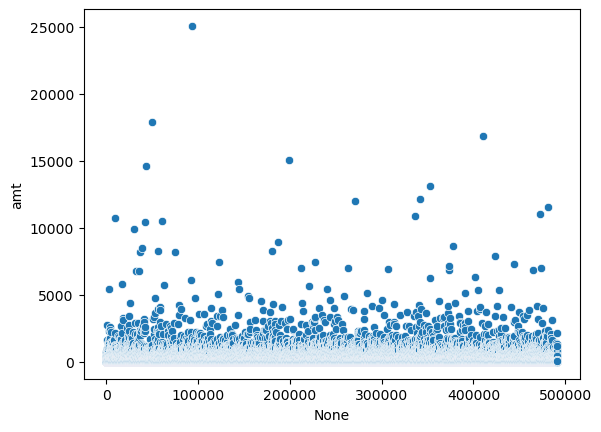

In [328]:
sns.scatterplot(x=drop_data.index, y=drop_data["amt"])

### 5) 구매금액 로그변환(amt_log) 변수
사기여부에는 일단 금액 컬럼이 중요하다고 생각되어 이상치를 확인해보는데  
금액 컬럼에 이상치들이 꽤나 보이고 금액 차이가 많이 나서...  
방법을 생각하다가 금액컬럼 로그변환 방법을 써보기로 결정! 

<Axes: ylabel='amt_log'>

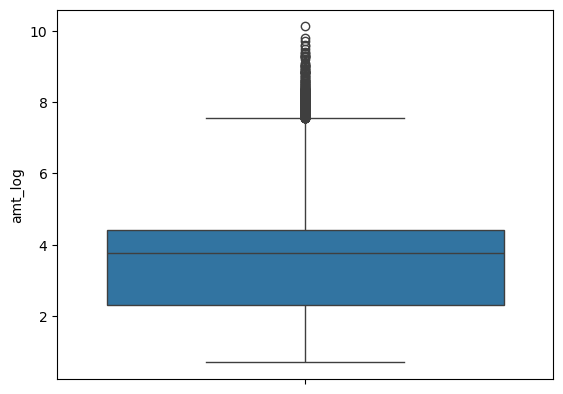

In [329]:
drop_data["amt_log"] = np.log1p(drop_data["amt"])
sns.boxplot(drop_data["amt_log"])

### 6) 고액 거래 여부(is_high_amt) 변수
사기 거래는 고액에서 많이 일어날 수 있을 것으로 예상하여 전체 금액의 95% 지점을 계산하여 상위 5% 고객 거래면 1, 나머지 고객 0

In [330]:
drop_data["is_high_amt"] = (drop_data["amt"] > drop_data["amt"].quantile(0.95)).astype(int)

## Step 2 - 1. 데이터의 위도/경도 정보를 활용해볼 수 있을까요?
### 7) 고객과 가맹점 거리(distance)
위도와 경도를 활용하여 고객과 실제 거래가 일어난 가맹점 거리를 측정  
고객이 보통 서울 근처에서 쓰는데 갑자기 수백 km 떨어진 곳에서 결제가 일어나면 의심해볼 상황!

In [331]:
!pip install geopy

In [332]:
from geopy.distance import geodesic

drop_data["distance"] = drop_data.apply(
    lambda x: geodesic(
        (x["lat"], x["long"]),
        (x["merch_lat"], x["merch_long"])
    ).km,
    axis=1
)

In [333]:
drop_data.head()

,trans_date_trans_time,category,amt,gender,city,state,zip,lat,long,city_pop,...,merch_long,is_fraud,hour,is_night,day_of_week,is_weekend,age,amt_log,is_high_amt,distance
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,99160,48.8878,-118.2105,149,...,-118.186462,0,0,1,1,0,41,4.684259,0,30.216618
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,7208,40.6747,-74.2239,124967,...,-74.848087,0,0,1,1,0,39,3.822317,0,84.714605
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,7060,40.6152,-74.4150,71485,...,-74.228188,0,0,1,1,0,45,3.856087,0,67.768167
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,48174,42.2203,-83.3583,31515,...,-83.552316,0,0,1,1,0,48,4.175771,0,22.322745
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,70808,30.4066,-91.1468,378909,...,-90.853194,0,0,1,1,0,42,3.280159,0,79.398244


In [334]:
print(drop_data["is_fraud"].value_counts())
print(drop_data["is_fraud"].value_counts(normalize=True))

is_fraud
0    489890
1      1244
Name: count, dtype: int64
is_fraud
0    0.997467
1    0.002533
Name: proportion, dtype: float64


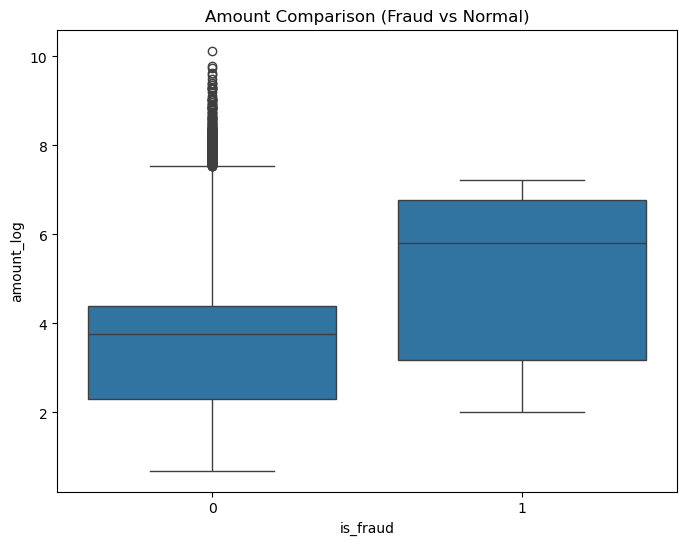

In [335]:
# 사기 vs 정상 거래 금액 비교

plt.figure(figsize=(8,6))
sns.boxplot(x="is_fraud", y="amt_log", data=drop_data)
plt.title("Amount Comparison (Fraud vs Normal)")
plt.xlabel("is_fraud")
plt.ylabel("amount_log")
plt.show()

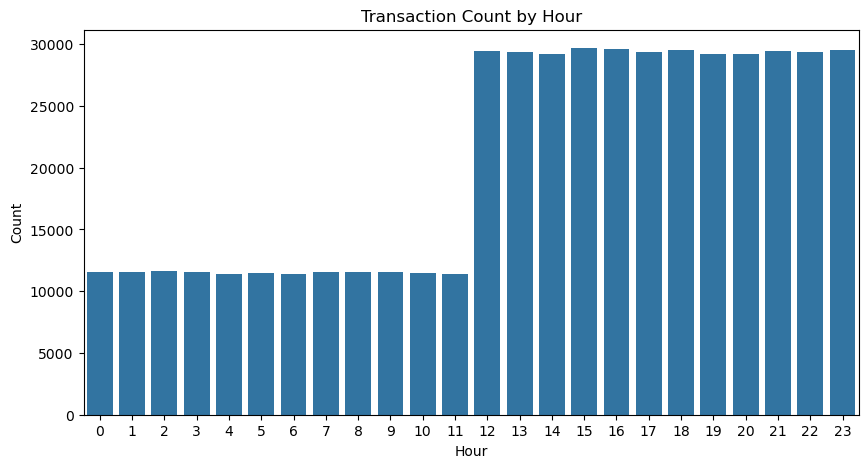

In [336]:
# 시간대별 거래 분포

plt.figure(figsize=(10,5))
sns.countplot(x="hour", data=drop_data)
plt.title("Transaction Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

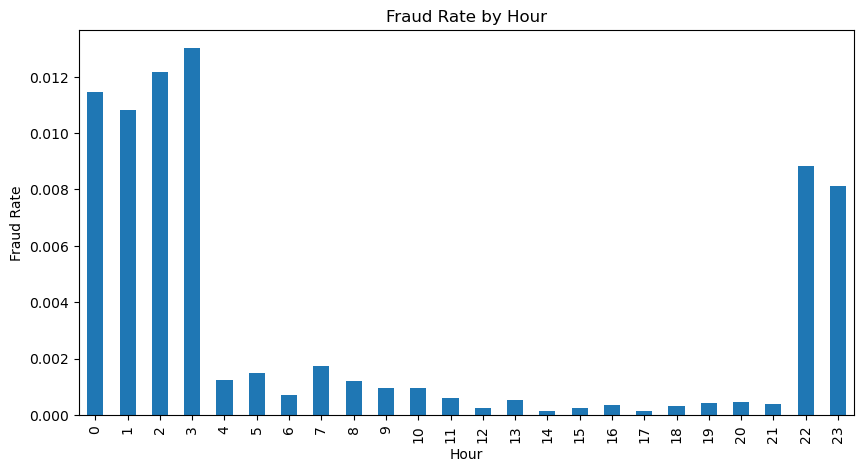

In [337]:
# 시간대별 사기 비율

hour_fraud_rate = drop_data.groupby("hour")["is_fraud"].mean()

plt.figure(figsize=(10,5))
hour_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

확실히 새벽/심야 시간(22시~03시)에 사기 비율이 다른 시간대에 높다는걸 알 수 있음

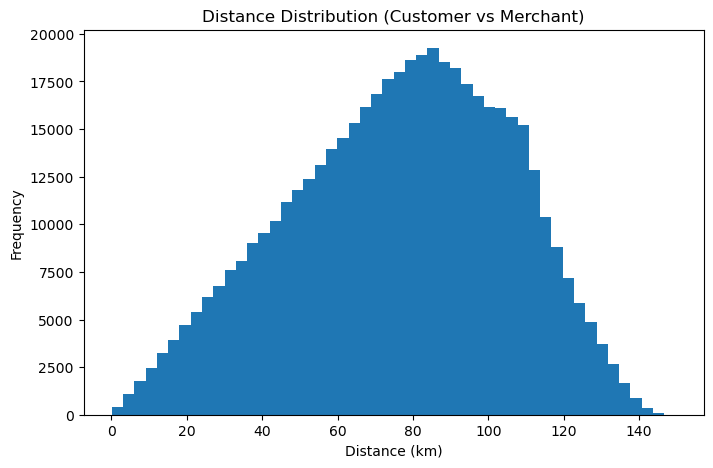

In [338]:
# 전체 거리 분포

plt.figure(figsize=(8,5))
plt.hist(drop_data["distance"], bins=50)
plt.title("Distance Distribution (Customer vs Merchant)")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

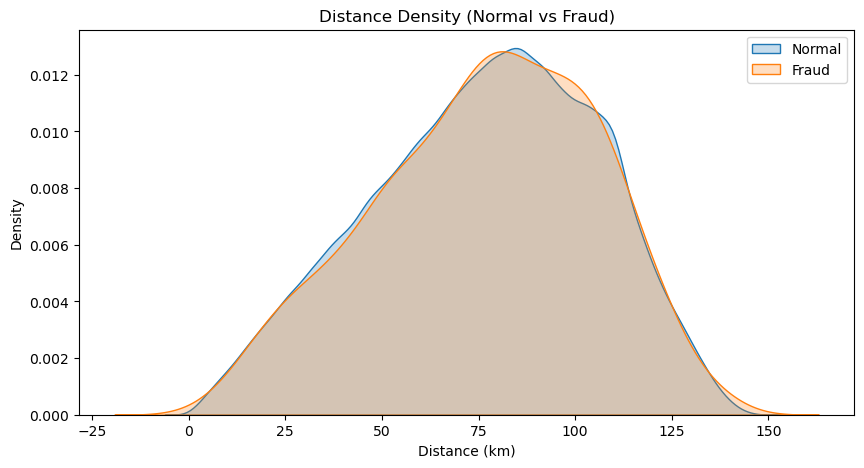

In [339]:
# 거리별로 사기와 정상 분포 비교

plt.figure(figsize=(10,5))
sns.kdeplot(data=drop_data[drop_data["is_fraud"]==0], x="distance", label="Normal", fill=True)
sns.kdeplot(data=drop_data[drop_data["is_fraud"]==1], x="distance", label="Fraud", fill=True)
plt.title("Distance Density (Normal vs Fraud)")
plt.xlabel("Distance (km)")
plt.ylabel("Density")
plt.legend()
plt.show()

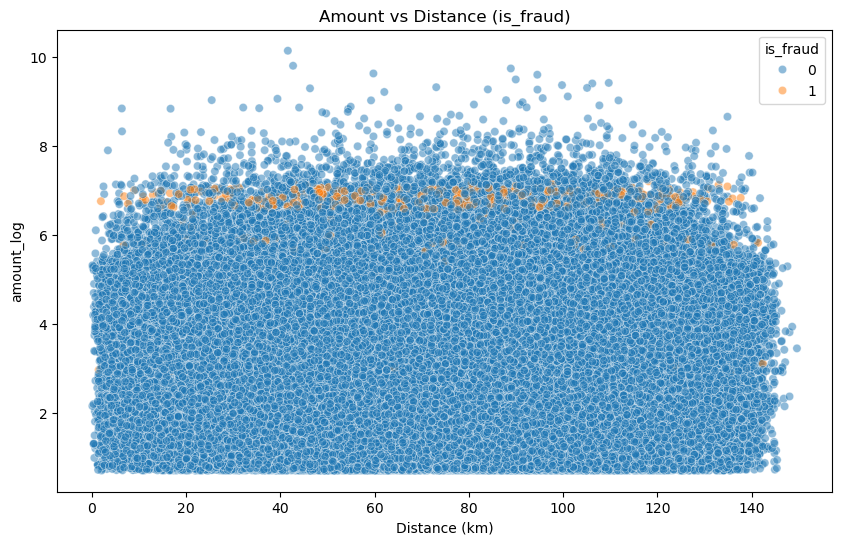

In [340]:
# 거리와 금액별 사기거래 여부

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=drop_data,
    x="distance",
    y="amt_log",
    hue="is_fraud",
    alpha=0.5
)
plt.title("Amount vs Distance (is_fraud)")
plt.xlabel("Distance (km)")
plt.ylabel("amount_log")
plt.show()

거리가 멀수록 사기거래가 더 많을 것으로 예상했으나 큰 차이가 없는 것으로 보임  
거리별로 다양하게 사기거래가 일어난 것을 확인함

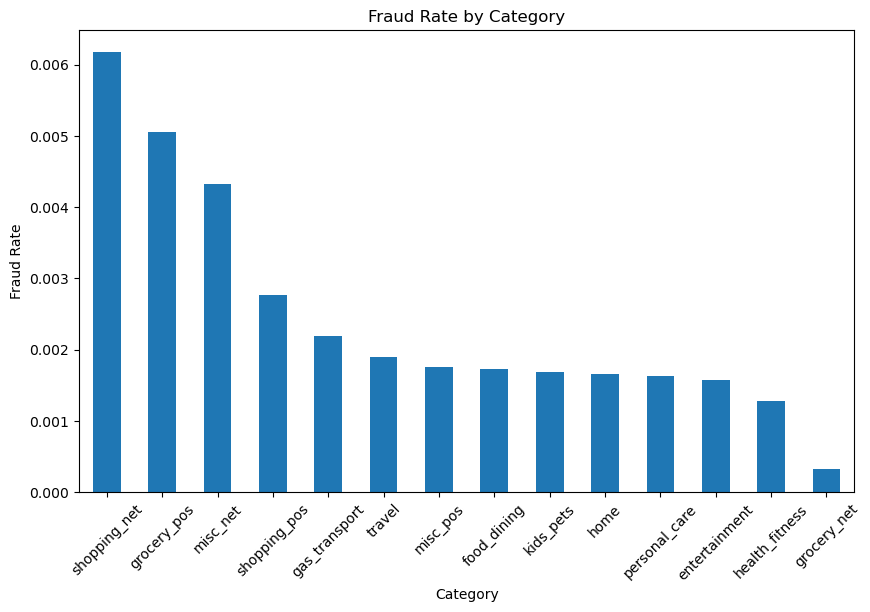

In [341]:
category_fraud_rate = drop_data.groupby("category")["is_fraud"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

특정 카테고리에서 사기 비율이 높게 나옴

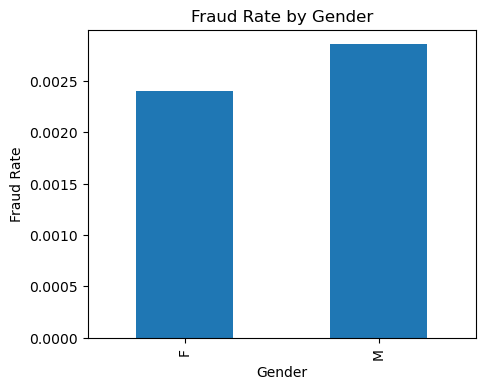

In [342]:
gender_fraud_rate = drop_data.groupby("gender")["is_fraud"].mean()

plt.figure(figsize=(5,4))
gender_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate")
plt.show()

In [343]:
drop_data["gender"].value_counts()

gender
F    352445
M    138689
Name: count, dtype: int64

In [344]:
drop_data["gender"] = (
    drop_data["gender"]
    .str.strip()      # 앞뒤 공백 제거
    .str.upper()      # 대문자로 통일
)

drop_data["gender"] = drop_data["gender"].map({"M": 0, "F": 1})

In [345]:
drop_data.head()

,trans_date_trans_time,category,amt,gender,city,state,zip,lat,long,city_pop,...,merch_long,is_fraud,hour,is_night,day_of_week,is_weekend,age,amt_log,is_high_amt,distance
0,2019-01-01 00:00:44,grocery_pos,107.23,1,Orient,WA,99160,48.8878,-118.2105,149,...,-118.186462,0,0,1,1,0,41,4.684259,0,30.216618
1,2019-01-01 00:12:34,grocery_pos,44.71,0,Elizabeth,NJ,7208,40.6747,-74.2239,124967,...,-74.848087,0,0,1,1,0,39,3.822317,0,84.714605
2,2019-01-01 00:17:16,grocery_net,46.28,1,Plainfield,NJ,7060,40.6152,-74.4150,71485,...,-74.228188,0,0,1,1,0,45,3.856087,0,67.768167
3,2019-01-01 00:20:15,grocery_pos,64.09,0,Romulus,MI,48174,42.2203,-83.3583,31515,...,-83.552316,0,0,1,1,0,48,4.175771,0,22.322745
4,2019-01-01 00:23:41,misc_pos,25.58,1,Baton Rouge,LA,70808,30.4066,-91.1468,378909,...,-90.853194,0,0,1,1,0,42,3.280159,0,79.398244


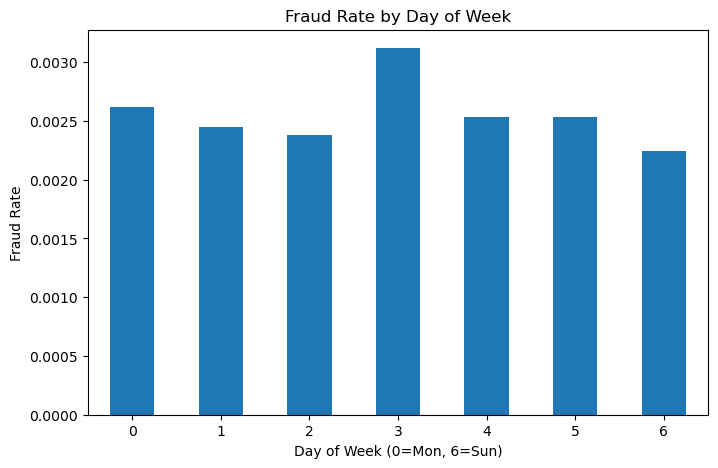

In [346]:
dow_fraud_rate = drop_data.groupby("day_of_week")["is_fraud"].mean()

plt.figure(figsize=(8,5))
dow_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.show()

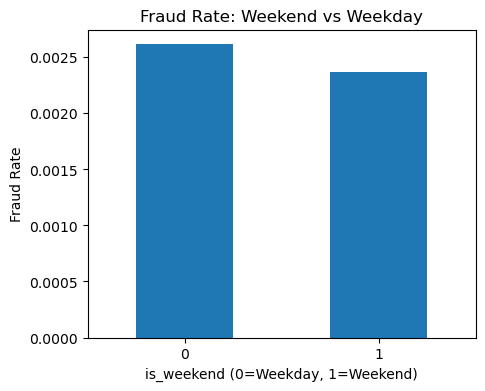

In [347]:
weekend_fraud_rate = drop_data.groupby("is_weekend")["is_fraud"].mean()

plt.figure(figsize=(5,4))
weekend_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate: Weekend vs Weekday")
plt.xlabel("is_weekend (0=Weekday, 1=Weekend)")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.show()

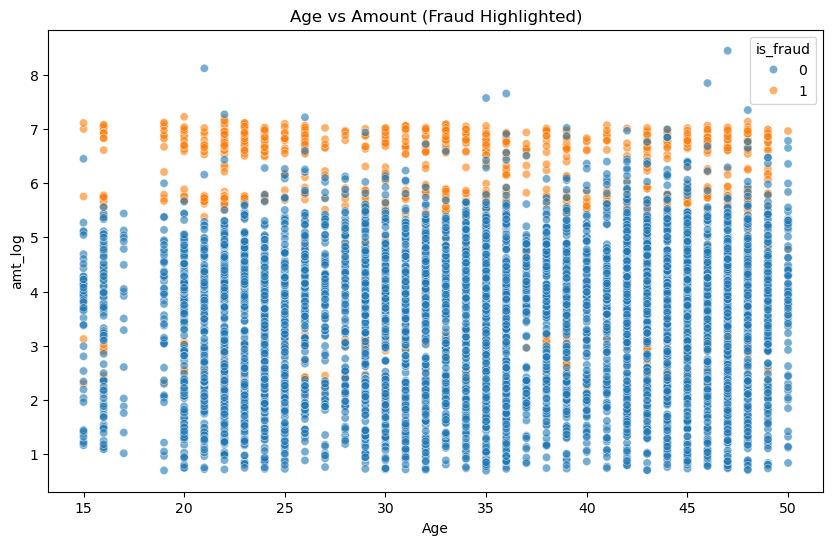

In [348]:
fraud = drop_data[drop_data["is_fraud"] == 1]
normal = drop_data[drop_data["is_fraud"] == 0].sample(n=len(fraud)*5, random_state=42)

sampled = pd.concat([fraud, normal])

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=sampled,
    x="age",
    y="amt_log",
    hue="is_fraud",
    alpha=0.6
)
plt.title("Age vs Amount (Fraud Highlighted)")
plt.xlabel("Age")
plt.ylabel("amt_log")
plt.show()


In [349]:
drop_data['is_fraud'].value_counts()

is_fraud
0    489890
1      1244
Name: count, dtype: int64

In [350]:
drop_data["is_high_amt"].value_counts()

is_high_amt
0    466580
1     24554
Name: count, dtype: int64

In [351]:
high_amt_fraud_rate = drop_data.groupby("is_high_amt")["is_fraud"].mean()
print(high_amt_fraud_rate)

is_high_amt
0    0.000853
1    0.034455
Name: is_fraud, dtype: float64


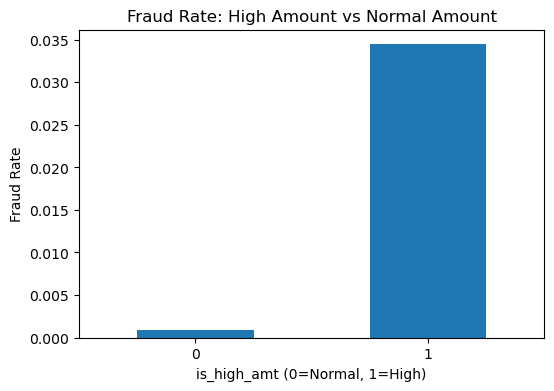

In [352]:
# 전체 고객 중 상위 5%(24554) vs 95%(466580) 각각의 사기거래 비율

plt.figure(figsize=(6,4))
high_amt_fraud_rate.plot(kind="bar")
plt.title("Fraud Rate: High Amount vs Normal Amount")
plt.xlabel("is_high_amt (0=Normal, 1=High)")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=0)
plt.show()

확실히 고액 거래에서 사기 비율이 엄청 높게 나오는걸 확인!  
대략 40배 정도 차이가 나는걸 확인할 수 있었음!

In [353]:
drop_data.groupby(["category", "is_high_amt"])["is_fraud"].mean()

category        is_high_amt
entertainment   0              0.000000
                1              0.033544
food_dining     0              0.001744
                1              0.000000
gas_transport   0              0.002194
grocery_net     0              0.000327
grocery_pos     0              0.000000
                1              0.038291
health_fitness  0              0.001295
                1              0.000000
home            0              0.000164
                1              0.085865
kids_pets       0              0.001716
                1              0.000000
misc_net        0              0.000000
                1              0.040520
misc_pos        0              0.001023
                1              0.008744
personal_care   0              0.001658
                1              0.000000
shopping_net    0              0.000000
                1              0.062662
shopping_pos    0              0.000000
                1              0.029971
travel      

특정 카테고리에서 고액 거래 시 사기율 급증하는 걸로 보임

In [354]:
drop_data.describe()

,trans_date_trans_time,amt,gender,zip,lat,long,city_pop,dob,unix_time,merch_lat,merch_long,is_fraud,hour,is_night,day_of_week,is_weekend,age,amt_log,is_high_amt,distance
count,491134,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,491134,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000,491134.000000
mean,2020-01-21 13:08:50.095035392,69.050120,0.717615,50770.532384,37.931230,-90.495619,1.213922e+05,1984-11-28 02:36:24.420545152,1.358730e+09,37.930272,-90.495411,0.002533,14.123087,0.237328,2.980873,0.332589,35.117905,3.467934,0.049995,76.371652
min,2019-01-01 00:00:44,1.000000,0.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1970-09-11 00:00:00,1.325376e+09,23.655789,-123.345106,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.693147,0.000000,0.124180
25%,2019-07-23 23:47:48.249999872,8.960000,0.000000,28405.000000,33.746700,-97.235100,1.228000e+03,1976-03-26 00:00:00,1.343087e+09,33.781388,-96.984814,0.000000,10.000000,0.000000,1.000000,0.000000,28.000000,2.298577,0.000000,55.604425
50%,2020-01-03 23:43:34.500000,42.170000,1.000000,49628.000000,38.507200,-87.591700,5.760000e+03,1984-09-01 00:00:00,1.357257e+09,38.545124,-87.573441,0.000000,15.000000,0.000000,3.000000,0.000000,35.000000,3.765146,0.000000,78.563223
75%,2020-07-24 00:30:18.500000,80.330000,1.000000,75048.000000,41.520500,-80.731000,5.083500e+04,1992-07-24 00:00:00,1.374626e+09,41.624294,-80.685567,0.000000,19.000000,0.000000,5.000000,1.000000,44.000000,4.398515,0.000000,98.720741
max,2020-12-31 23:59:34,25086.940000,1.000000,99323.000000,48.887800,-69.965600,2.906700e+06,2004-12-30 00:00:00,1.388534e+09,49.887523,-68.965624,1.000000,23.000000,1.000000,6.000000,1.000000,50.000000,10.130143,1.000000,149.610127
std,NaN,160.322867,0.450160,26854.947965,5.341193,12.990732,3.725751e+05,NaN,1.819402e+07,5.372986,13.004100,0.050264,6.406759,0.425446,2.209188,0.471141,9.304940,1.314505,0.217934,29.143508


## 🌳 RandomForest
일단 냅다 범주형 제외하고 숫자형들로 베이스 모델 진행해보자!

In [355]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score

# 타겟/피처 분리
y = drop_data["is_fraud"]

# 숫자형만 사용 (범주형 자동 제외)
X = drop_data.select_dtypes(include=["number"]).drop(columns=["is_fraud"], errors="ignore")

print("사용 피처 수:", X.shape[1])
print(X.columns)

사용 피처 수: 17
Index(['amt', 'gender', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'hour', 'is_night', 'day_of_week',
       'is_weekend', 'age', 'amt_log', 'is_high_amt', 'distance'],
      dtype='object')


In [356]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [357]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [358]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

Confusion Matrix
 [[97962    16]
 [  157    92]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.85      0.37      0.52       249

    accuracy                           1.00     98227
   macro avg       0.93      0.68      0.76     98227
weighted avg       1.00      1.00      1.00     98227

ROC-AUC: 0.9568199721255349
PR-AUC (Average Precision): 0.5589699558008578


일단 정상거래를 사기로 잘못 판단 16건  
사기인데 정상이라고 판단 157건...  
FN(놓친 사기)가 너무 커서 줄여봐야함...  
recall 0.37 너무 낮긴해요...

c:\Users\master\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\master\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


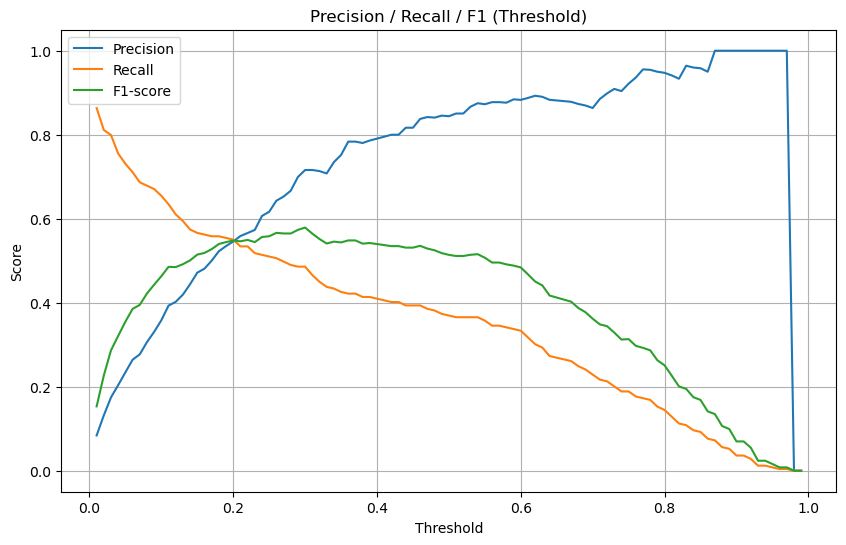

In [359]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.01, 1.00, 0.01)

precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_th = (y_proba >= t).astype(int)
    
    precisions.append(precision_score(y_test, y_pred_th))
    recalls.append(recall_score(y_test, y_pred_th))
    f1s.append(f1_score(y_test, y_pred_th))

plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1-score")

plt.title("Precision / Recall / F1 (Threshold)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


In [371]:
# threshold 0.2로 조정

threshold = 0.2

y_pred_new = (y_proba >= threshold).astype(int)

print("Confusion Matrix (threshold=0.2)\n")
print(confusion_matrix(y_test, y_pred_new))
print("\nClassification Report (threshold=0.2)\n")
print(classification_report(y_test, y_pred_new))

Confusion Matrix (threshold=0.2)

[[97638   340]
 [   19   230]]

Classification Report (threshold=0.2)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.40      0.92      0.56       249

    accuracy                           1.00     98227
   macro avg       0.70      0.96      0.78     98227
weighted avg       1.00      1.00      1.00     98227



음... recall 수치 살짝 올라오긴 했는데...  
아직도 수치가 그렇게 좋지 않은 것 같아서...  
카테고리 인코딩진행해서 다시...

In [361]:
# category 컬럼 원 핫 인코딩, 파생변수 만든 원래 컬럼 제거
df = drop_data.copy()
df = pd.get_dummies(df, columns=["category"], drop_first=True)

df = df.drop(columns=["trans_date_trans_time", "dob"], errors="ignore")

In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 34 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   amt                      491134 non-null  float64
 1   gender                   491134 non-null  int64  
 2   city                     491134 non-null  object 
 3   state                    491134 non-null  object 
 4   zip                      491134 non-null  int64  
 5   lat                      491134 non-null  float64
 6   long                     491134 non-null  float64
 7   city_pop                 491134 non-null  int64  
 8   job                      491134 non-null  object 
 9   unix_time                491134 non-null  int64  
 10  merch_lat                491134 non-null  float64
 11  merch_long               491134 non-null  float64
 12  is_fraud                 491134 non-null  int64  
 13  hour                     491134 non-null  int32  
 14  is_n

In [363]:
y = df["is_fraud"]
X = df.select_dtypes(include=["number", "bool"]).drop(columns=["is_fraud"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_2 = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_2.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [364]:
y_pred = rf_2.predict(X_test)
y_proba = rf_2.predict_proba(X_test)[:, 1]

print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

Confusion Matrix
 [[97966    12]
 [  122   127]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.91      0.51      0.65       249

    accuracy                           1.00     98227
   macro avg       0.96      0.75      0.83     98227
weighted avg       1.00      1.00      1.00     98227

ROC-AUC: 0.9832664057606243
PR-AUC: 0.7562430660046036


In [372]:
threshold = 0.2
y_pred_th = (y_proba >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_th))
print(classification_report(y_test, y_pred_th))

[[97638   340]
 [   19   230]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.40      0.92      0.56       249

    accuracy                           1.00     98227
   macro avg       0.70      0.96      0.78     98227
weighted avg       1.00      1.00      1.00     98227



## 🚀 XGBoost
여러 개의 작은 결정트리를 순차적으로 만들어가면서  
이전 모델이 틀린 부분을 계속 보완하는 모델?  
궁금해서 한번 도전...!

In [366]:
!pip install xgboost

In [368]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

# 불균형 비율 계산
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

print("Confusion Matrix\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))

Confusion Matrix
 [[97835   143]
 [   33   216]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     97978
           1       0.60      0.87      0.71       249

    accuracy                           1.00     98227
   macro avg       0.80      0.93      0.85     98227
weighted avg       1.00      1.00      1.00     98227

ROC-AUC: 0.9990157613449983
PR-AUC: 0.880673563685196


## ✨ 최종 결론
🔹 RandomForest  
숫자형 컬럼들로만 진행했을 때 사기를 많이 놓침

📌 일단 이 모델은 사기 거래를 예측하는 모델을 구축해야하므로 전체적인 수치를 봤을 때 FN을 낮추서 recall 점수를 올려야 하는 모델이라고 판단  
👉 정상거래를 사기거래로 오해하는 것이 사기거래를 정상거래라고 판단하는 것보다 손실이 더 적을 것으로 생각했기 때문!

🔹 RandomForest + Category   
카테고리 컬럼 원 핫 인코딩 진행했을 때 확실히 FN이 줄어드는 경향으로 보아 카테고리 정보가 꽤나 중요한 컬럼인걸로 보임

🔹 RandomForest + threshold 0.2  
threshold 0.2로 조정하였을 때 FN이 더 많이 줄어들어 recall 점수가 많이 올라감

✅ **XGBoost** - 최종 모델로 선정!  
recall이 0.87로 사기를 87% 탐지하며 사기 예측 중 60%가 실제 사기로 생각보다 낮은 비율이지만 FN이 33개로 매우 감소하였고,   
PR-AUC = 0.88로 불균형 데이터에서 매우 우수한 성능이므로 최종 모델로 선정하였음  
아무래도 극심한 불균형 데이터에는 렌덤포레스트도 좋지만 XGBoost 모델도 좋은 모델인듯 보임!

